# HW08-09: PyTorch MLP — Регуляризация и Оптимизация

**Датасет:** EMNIST `split="balanced"` (Вариант B)  
**Часть A (S08):** Dropout, BatchNorm, EarlyStopping — эксперименты E1–E4  
**Часть B (S09):** LR-диагностика, SGD+momentum, weight_decay — эксперименты O1–O3

## 1. Импорты, seed и устройство

In [1]:
import os
import json
import csv
import copy
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import EMNIST

print(f'PyTorch      : {torch.__version__}')
print(f'Torchvision  : {torchvision.__version__}')

PyTorch      : 2.10.0+cpu
Torchvision  : 0.25.0+cpu


In [2]:
# ── Глобальный seed ───────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)

# ── Устройство ────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

# ── Директории артефактов ─────────────────────────────────────────────────────
ARTIFACTS_DIR = 'artifacts'
FIGURES_DIR   = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Artifacts : {ARTIFACTS_DIR}/')

Device : cpu
Artifacts : artifacts/


## 2. Данные и DataLoader

**EMNIST split="balanced"**:  
- 112 800 train / 18 800 test примеров  
- 47 классов (цифры 0–9 + латинские буквы, сбалансированные)  
- 28×28 grayscale  

In [3]:
# ── Трансформации ─────────────────────────────────────────────────────────────
# Нормализуем по mean/std, характерным для EMNIST balanced
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1736,), (0.3317,))
])

DATASET_NAME = 'EMNIST_balanced'
DATA_ROOT    = './data'
NUM_CLASSES  = 47

# ── Загрузка ──────────────────────────────────────────────────────────────────
full_train_dataset = EMNIST(root=DATA_ROOT, split='balanced',
                            train=True,  download=True, transform=transform)
test_dataset       = EMNIST(root=DATA_ROOT, split='balanced',
                            train=False, download=True, transform=transform)

print(f'Full train : {len(full_train_dataset):,}')
print(f'Test       : {len(test_dataset):,}')
print(f'Num classes: {NUM_CLASSES}')

100.0%


Full train : 112,800
Test       : 18,800
Num classes: 47


In [4]:
# ── Train / Val split  80 / 20, воспроизводимо ───────────────────────────────
TRAIN_RATIO = 0.8
n_total = len(full_train_dataset)
n_train = int(n_total * TRAIN_RATIO)
n_val   = n_total - n_train

generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [n_train, n_val], generator=generator
)

print(f'Train : {len(train_dataset):,}  |  Val : {len(val_dataset):,}  |  Test : {len(test_dataset):,}')

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE  = 256
NUM_WORKERS = 0
PIN_MEMORY  = (DEVICE.type == 'cuda')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# ── Sanity-check ──────────────────────────────────────────────────────────────
x_batch, y_batch = next(iter(train_loader))
print(f'\nSanity check:')
print(f'  x.shape  : {x_batch.shape}   (batch, C, H, W)')
print(f'  y.shape  : {y_batch.shape}   (batch,)')
print(f'  x range  : [{x_batch.min():.3f}, {x_batch.max():.3f}]')
print(f'  y range  : [{y_batch.min().item()}, {y_batch.max().item()}]')

Train : 90,240  |  Val : 22,560  |  Test : 18,800

Sanity check:
  x.shape  : torch.Size([256, 1, 28, 28])   (batch, C, H, W)
  y.shape  : torch.Size([256])   (batch,)
  x range  : [-0.523, 2.491]
  y range  : [0, 46]


## 3. Модель MLP и утилиты обучения

In [5]:
class MLP(nn.Module):
    """
    Гибкий MLP-классификатор.

    Параметры
    ---------
    hidden_sizes  : список размеров скрытых слоёв, напр. [512, 256, 128]
    dropout_p     : вероятность Dropout (0.0 = без Dropout)
    use_batchnorm : True → BatchNorm1d после каждого Linear, перед ReLU
    """
    def __init__(
        self,
        input_size:    int   = 28 * 28,
        hidden_sizes:  list  = None,
        num_classes:   int   = 47,
        dropout_p:     float = 0.0,
        use_batchnorm: bool  = False,
    ):
        super().__init__()
        if hidden_sizes is None:
            hidden_sizes = [512, 256, 128]

        layers  = [nn.Flatten()]
        in_feat = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(in_feat, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
            in_feat = h
        layers.append(nn.Linear(in_feat, num_classes))   # logits

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# ── Быстрая проверка ──────────────────────────────────────────────────────────
_m = MLP(hidden_sizes=[512, 256, 128], num_classes=NUM_CLASSES,
         dropout_p=0.3, use_batchnorm=True).to(DEVICE)
_x = torch.randn(4, 1, 28, 28).to(DEVICE)
print(f'Output shape : {_m(_x).shape}')   # (4, 47)
print(f'Params       : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _x

Output shape : torch.Size([4, 47])
Params       : 573,999


In [6]:
# ── train / eval ──────────────────────────────────────────────────────────────
CRITERION = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer,
                    criterion=CRITERION, device=DEVICE):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=CRITERION, device=DEVICE):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


print('train_one_epoch / evaluate — готовы')

train_one_epoch / evaluate — готовы


In [7]:
# ── EarlyStopping ─────────────────────────────────────────────────────────────
class EarlyStopping:
    """
    Останавливает обучение, если val_loss не улучшается `patience` эпох подряд.
    Хранит deepcopy лучших весов модели.
    """
    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience      = patience
        self.min_delta     = min_delta
        self.counter       = 0
        self.best_loss     = float('inf')
        self.best_state    = None
        self.stopped_epoch = 0

    def step(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        """Возвращает True, если нужно остановиться."""
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
        if self.counter >= self.patience:
            self.stopped_epoch = epoch
            return True
        return False

    def restore_best(self, model: nn.Module):
        """Загружает в модель лучшие сохранённые веса."""
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


print('EarlyStopping — готов')

EarlyStopping — готов


In [8]:
# ── Полный цикл обучения ──────────────────────────────────────────────────────
def run_training(
    model,
    optimizer,
    num_epochs: int,
    early_stopping: EarlyStopping = None,
    verbose: bool = True,
):
    """
    Возвращает dict с историей обучения:
    'train_loss', 'val_loss', 'train_acc', 'val_acc'.
    """
    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        vl_loss, vl_acc = evaluate(model, val_loader)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(f'  epoch {epoch:>3}/{num_epochs} | '
                  f'train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f} | '
                  f'train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}')

        if early_stopping is not None and early_stopping.step(vl_loss, model, epoch):
            if verbose:
                print(f'  [EarlyStopping] остановка на эпохе {epoch} '
                      f'(patience={early_stopping.patience})')
            break

    return history


print('run_training — готов')

run_training — готов


---
## 4. Часть A (S08): Регуляризация и переобучение

| Параметр        | Значение |
|:----------------|:---------|
| Архитектура     | `[512 → 256 → 128 → 47]` + ReLU |
| Optimizer       | Adam, lr = 1e-3 |
| Эпох (E1–E3)    | 20 (одинаково для корректного сравнения) |
| Loss            | CrossEntropyLoss |

In [9]:
HIDDEN_SIZES   = [512, 256, 128]
LR_DEFAULT     = 1e-3
NUM_EPOCHS_REG = 20

### E1 — Base MLP (без Dropout, без BatchNorm)

In [10]:
print('=' * 60)
print('E1  Base MLP — без Dropout, без BatchNorm')
print('=' * 60)

set_seed(SEED)
model_e1 = MLP(hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_p=0.0, use_batchnorm=False).to(DEVICE)
optim_e1 = optim.Adam(model_e1.parameters(), lr=LR_DEFAULT)
hist_e1  = run_training(model_e1, optim_e1, NUM_EPOCHS_REG)

best_val_acc_e1  = max(hist_e1['val_acc'])
best_val_loss_e1 = min(hist_e1['val_loss'])
print(f'\nE1  best_val_acc={best_val_acc_e1:.4f}   best_val_loss={best_val_loss_e1:.4f}')

E1  Base MLP — без Dropout, без BatchNorm
  epoch   1/20 | train_loss=1.1221  val_loss=0.7044 | train_acc=0.6683  val_acc=0.7778
  epoch   5/20 | train_loss=0.3746  val_loss=0.4632 | train_acc=0.8644  val_acc=0.8442
  epoch  10/20 | train_loss=0.2479  val_loss=0.4971 | train_acc=0.9023  val_acc=0.8477
  epoch  15/20 | train_loss=0.1951  val_loss=0.5776 | train_acc=0.9190  val_acc=0.8466
  epoch  20/20 | train_loss=0.1552  val_loss=0.6980 | train_acc=0.9349  val_acc=0.8371

E1  best_val_acc=0.8488   best_val_loss=0.4632


### E2 — MLP + Dropout (p = 0.3)

In [11]:
print('=' * 60)
print('E2  MLP + Dropout (p=0.3)')
print('=' * 60)

set_seed(SEED)
model_e2 = MLP(hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_p=0.3, use_batchnorm=False).to(DEVICE)
optim_e2 = optim.Adam(model_e2.parameters(), lr=LR_DEFAULT)
hist_e2  = run_training(model_e2, optim_e2, NUM_EPOCHS_REG)

best_val_acc_e2  = max(hist_e2['val_acc'])
best_val_loss_e2 = min(hist_e2['val_loss'])
print(f'\nE2  best_val_acc={best_val_acc_e2:.4f}   best_val_loss={best_val_loss_e2:.4f}')

E2  MLP + Dropout (p=0.3)
  epoch   1/20 | train_loss=1.4796  val_loss=0.7487 | train_acc=0.5671  val_acc=0.7636
  epoch   5/20 | train_loss=0.6069  val_loss=0.4949 | train_acc=0.7992  val_acc=0.8348
  epoch  10/20 | train_loss=0.5009  val_loss=0.4434 | train_acc=0.8259  val_acc=0.8494
  epoch  15/20 | train_loss=0.4563  val_loss=0.4358 | train_acc=0.8403  val_acc=0.8526
  epoch  20/20 | train_loss=0.4291  val_loss=0.4311 | train_acc=0.8469  val_acc=0.8561

E2  best_val_acc=0.8590   best_val_loss=0.4278


### E3 — MLP + BatchNorm

In [12]:
print('=' * 60)
print('E3  MLP + BatchNorm')
print('=' * 60)

set_seed(SEED)
model_e3 = MLP(hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
               dropout_p=0.0, use_batchnorm=True).to(DEVICE)
optim_e3 = optim.Adam(model_e3.parameters(), lr=LR_DEFAULT)
hist_e3  = run_training(model_e3, optim_e3, NUM_EPOCHS_REG)

best_val_acc_e3  = max(hist_e3['val_acc'])
best_val_loss_e3 = min(hist_e3['val_loss'])
print(f'\nE3  best_val_acc={best_val_acc_e3:.4f}   best_val_loss={best_val_loss_e3:.4f}')

E3  MLP + BatchNorm
  epoch   1/20 | train_loss=0.9944  val_loss=0.5668 | train_acc=0.7409  val_acc=0.8161
  epoch   5/20 | train_loss=0.3156  val_loss=0.4555 | train_acc=0.8826  val_acc=0.8467
  epoch  10/20 | train_loss=0.2122  val_loss=0.4601 | train_acc=0.9145  val_acc=0.8521
  epoch  15/20 | train_loss=0.1614  val_loss=0.5114 | train_acc=0.9323  val_acc=0.8525
  epoch  20/20 | train_loss=0.1319  val_loss=0.5824 | train_acc=0.9455  val_acc=0.8460

E3  best_val_acc=0.8547   best_val_loss=0.4319


### Выбор лучшего между E2 и E3 → архитектура для E4

In [13]:
print('Сравнение E2 vs E3 по best val_accuracy:')
print(f'  E2 (Dropout p=0.3) : {best_val_acc_e2:.4f}')
print(f'  E3 (BatchNorm)     : {best_val_acc_e3:.4f}')

if best_val_acc_e2 >= best_val_acc_e3:
    best_from   = 'E2'
    best_kwargs = dict(hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
                       dropout_p=0.3, use_batchnorm=False)
    print('\n→ Выбрана E2 (Dropout p=0.3)')
else:
    best_from   = 'E3'
    best_kwargs = dict(hidden_sizes=HIDDEN_SIZES, num_classes=NUM_CLASSES,
                       dropout_p=0.0, use_batchnorm=True)
    print('\n→ Выбрана E3 (BatchNorm)')

Сравнение E2 vs E3 по best val_accuracy:
  E2 (Dropout p=0.3) : 0.8590
  E3 (BatchNorm)     : 0.8547

→ Выбрана E2 (Dropout p=0.3)


### E4 — Лучшая архитектура + EarlyStopping (patience = 5)

In [14]:
print('=' * 60)
print(f'E4  {best_from} + EarlyStopping (patience=5, max_epochs=50)')
print('=' * 60)

set_seed(SEED)
model_e4 = MLP(**best_kwargs).to(DEVICE)
optim_e4 = optim.Adam(model_e4.parameters(), lr=LR_DEFAULT)
es_e4    = EarlyStopping(patience=5, min_delta=1e-4)

hist_e4 = run_training(model_e4, optim_e4, num_epochs=50, early_stopping=es_e4)

# Восстанавливаем лучшие веса
es_e4.restore_best(model_e4)

best_val_acc_e4  = max(hist_e4['val_acc'])
best_val_loss_e4 = min(hist_e4['val_loss'])
epochs_e4        = len(hist_e4['train_loss'])

print(f'\nE4  обучено эпох={epochs_e4}  '
      f'best_val_acc={best_val_acc_e4:.4f}  best_val_loss={best_val_loss_e4:.4f}')

E4  E2 + EarlyStopping (patience=5, max_epochs=50)
  epoch   1/50 | train_loss=1.4796  val_loss=0.7487 | train_acc=0.5671  val_acc=0.7636
  epoch   5/50 | train_loss=0.6069  val_loss=0.4949 | train_acc=0.7992  val_acc=0.8348
  epoch  10/50 | train_loss=0.5009  val_loss=0.4434 | train_acc=0.8259  val_acc=0.8494
  epoch  15/50 | train_loss=0.4563  val_loss=0.4358 | train_acc=0.8403  val_acc=0.8526
  epoch  20/50 | train_loss=0.4291  val_loss=0.4311 | train_acc=0.8469  val_acc=0.8561
  epoch  25/50 | train_loss=0.4053  val_loss=0.4327 | train_acc=0.8536  val_acc=0.8559
  epoch  30/50 | train_loss=0.3886  val_loss=0.4244 | train_acc=0.8591  val_acc=0.8588
  [EarlyStopping] остановка на эпохе 34 (patience=5)

E4  обучено эпох=34  best_val_acc=0.8602  best_val_loss=0.4237


### Финальная оценка E4 на тестовой выборке (один раз)

In [15]:
test_loss, test_acc = evaluate(model_e4, test_loader)
print('━' * 45)
print(f'  TEST  loss     : {test_loss:.4f}')
print(f'  TEST  accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)')
print('━' * 45)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  TEST  loss     : 0.4396
  TEST  accuracy : 0.8545  (85.45%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### График E4 → `artifacts/figures/curves_best.png`

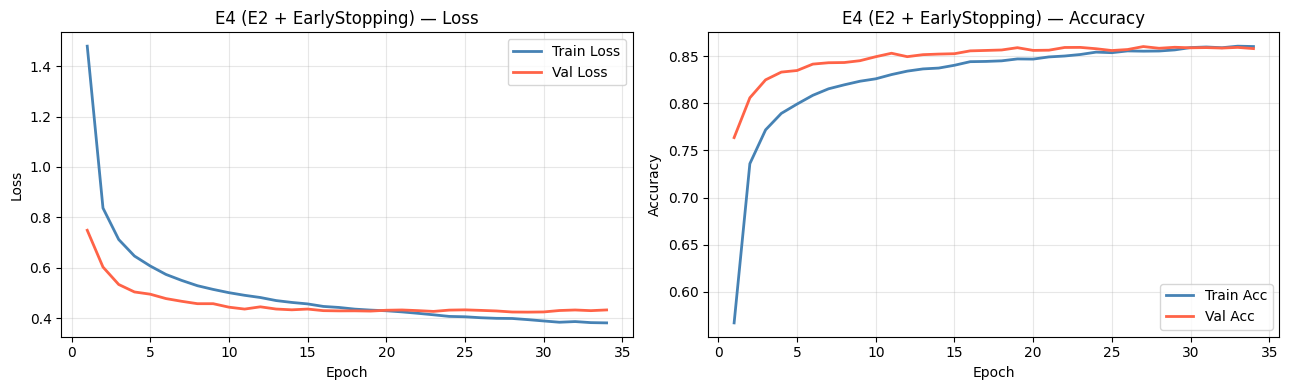

Saved → artifacts\figures\curves_best.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, epochs_e4 + 1)

axes[0].plot(ep, hist_e4['train_loss'], label='Train Loss', color='steelblue', lw=2)
axes[0].plot(ep, hist_e4['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
axes[0].set_title(f'E4 ({best_from} + EarlyStopping) — Loss', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, hist_e4['train_acc'], label='Train Acc', color='steelblue', lw=2)
axes[1].plot(ep, hist_e4['val_acc'],   label='Val Acc',   color='tomato',    lw=2)
axes[1].set_title(f'E4 ({best_from} + EarlyStopping) — Accuracy', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
_path = os.path.join(FIGURES_DIR, 'curves_best.png')
fig.savefig(_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {_path}')

### Сводный график E1–E4 → `artifacts/figures/curves_regularization_summary.png`

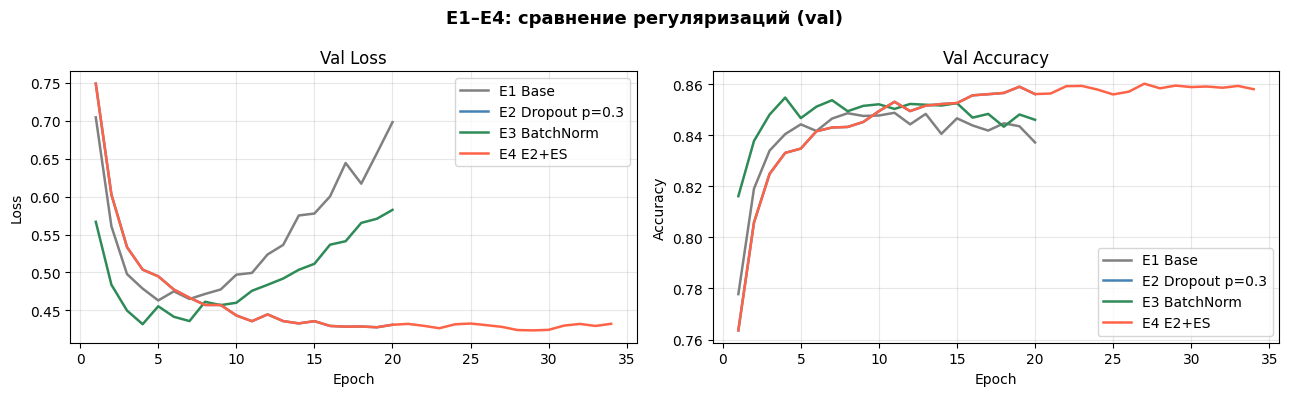

Saved → artifacts\figures\curves_regularization_summary.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('E1–E4: сравнение регуляризаций (val)', fontsize=13, fontweight='bold')

for hist, label, color in [
    (hist_e1, 'E1 Base',            'gray'),
    (hist_e2, 'E2 Dropout p=0.3',   'steelblue'),
    (hist_e3, 'E3 BatchNorm',       'seagreen'),
    (hist_e4, f'E4 {best_from}+ES', 'tomato'),
]:
    ep = range(1, len(hist['val_loss']) + 1)
    axes[0].plot(ep, hist['val_loss'], label=label, color=color, lw=1.8)
    axes[1].plot(ep, hist['val_acc'],  label=label, color=color, lw=1.8)

axes[0].set_title('Val Loss');     axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Val Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
_path = os.path.join(FIGURES_DIR, 'curves_regularization_summary.png')
fig.savefig(_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {_path}')

---
## 5. Часть B (S09): LR-диагностика, оптимизаторы, weight decay

Все эксперименты используют **ту же архитектуру, что в E4**.

### O1 — Adam, lr = 1e-1 (слишком большой)

In [18]:
NUM_EPOCHS_DIAG = 8

print('=' * 60)
print('O1  Adam  lr=1e-1  (слишком большой LR)')
print('=' * 60)

set_seed(SEED)
model_o1 = MLP(**best_kwargs).to(DEVICE)
optim_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)
hist_o1  = run_training(model_o1, optim_o1, NUM_EPOCHS_DIAG)

best_val_acc_o1  = max(hist_o1['val_acc'])
best_val_loss_o1 = min(hist_o1['val_loss'])
print(f'\nO1  best_val_acc={best_val_acc_o1:.4f}')

O1  Adam  lr=1e-1  (слишком большой LR)
  epoch   1/8 | train_loss=16.4254  val_loss=3.8653 | train_acc=0.0218  val_acc=0.0215
  epoch   5/8 | train_loss=3.8708  val_loss=3.8555 | train_acc=0.0203  val_acc=0.0218

O1  best_val_acc=0.0227


### O2 — Adam, lr = 1e-5 (слишком маленький)

In [19]:
print('=' * 60)
print('O2  Adam  lr=1e-5  (слишком маленький LR)')
print('=' * 60)

set_seed(SEED)
model_o2 = MLP(**best_kwargs).to(DEVICE)
optim_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
hist_o2  = run_training(model_o2, optim_o2, NUM_EPOCHS_DIAG)

best_val_acc_o2  = max(hist_o2['val_acc'])
best_val_loss_o2 = min(hist_o2['val_loss'])
print(f'\nO2  best_val_acc={best_val_acc_o2:.4f}')

O2  Adam  lr=1e-5  (слишком маленький LR)
  epoch   1/8 | train_loss=3.8139  val_loss=3.7282 | train_acc=0.0466  val_acc=0.1317
  epoch   5/8 | train_loss=2.6030  val_loss=2.1497 | train_acc=0.2952  val_acc=0.4994

O2  best_val_acc=0.5727


### O3 — SGD + momentum = 0.9 + weight_decay = 1e-4

In [20]:
LR_SGD         = 1e-2
MOMENTUM       = 0.9
WEIGHT_DECAY   = 1e-4
NUM_EPOCHS_SGD = 15

print('=' * 60)
print(f'O3  SGD  lr={LR_SGD}  momentum={MOMENTUM}  weight_decay={WEIGHT_DECAY}')
print('=' * 60)

set_seed(SEED)
model_o3 = MLP(**best_kwargs).to(DEVICE)
optim_o3 = optim.SGD(model_o3.parameters(),
                     lr=LR_SGD, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
hist_o3  = run_training(model_o3, optim_o3, NUM_EPOCHS_SGD)

best_val_acc_o3  = max(hist_o3['val_acc'])
best_val_loss_o3 = min(hist_o3['val_loss'])
print(f'\nO3  best_val_acc={best_val_acc_o3:.4f}   best_val_loss={best_val_loss_o3:.4f}')

O3  SGD  lr=0.01  momentum=0.9  weight_decay=0.0001
  epoch   1/15 | train_loss=2.6842  val_loss=1.2780 | train_acc=0.2802  val_acc=0.6293
  epoch   5/15 | train_loss=0.8163  val_loss=0.6151 | train_acc=0.7408  val_acc=0.8044
  epoch  10/15 | train_loss=0.6216  val_loss=0.4977 | train_acc=0.7953  val_acc=0.8349
  epoch  15/15 | train_loss=0.5367  val_loss=0.4600 | train_acc=0.8194  val_acc=0.8444

O3  best_val_acc=0.8444   best_val_loss=0.4600


### График LR-диагностики → `artifacts/figures/curves_lr_extremes.png`

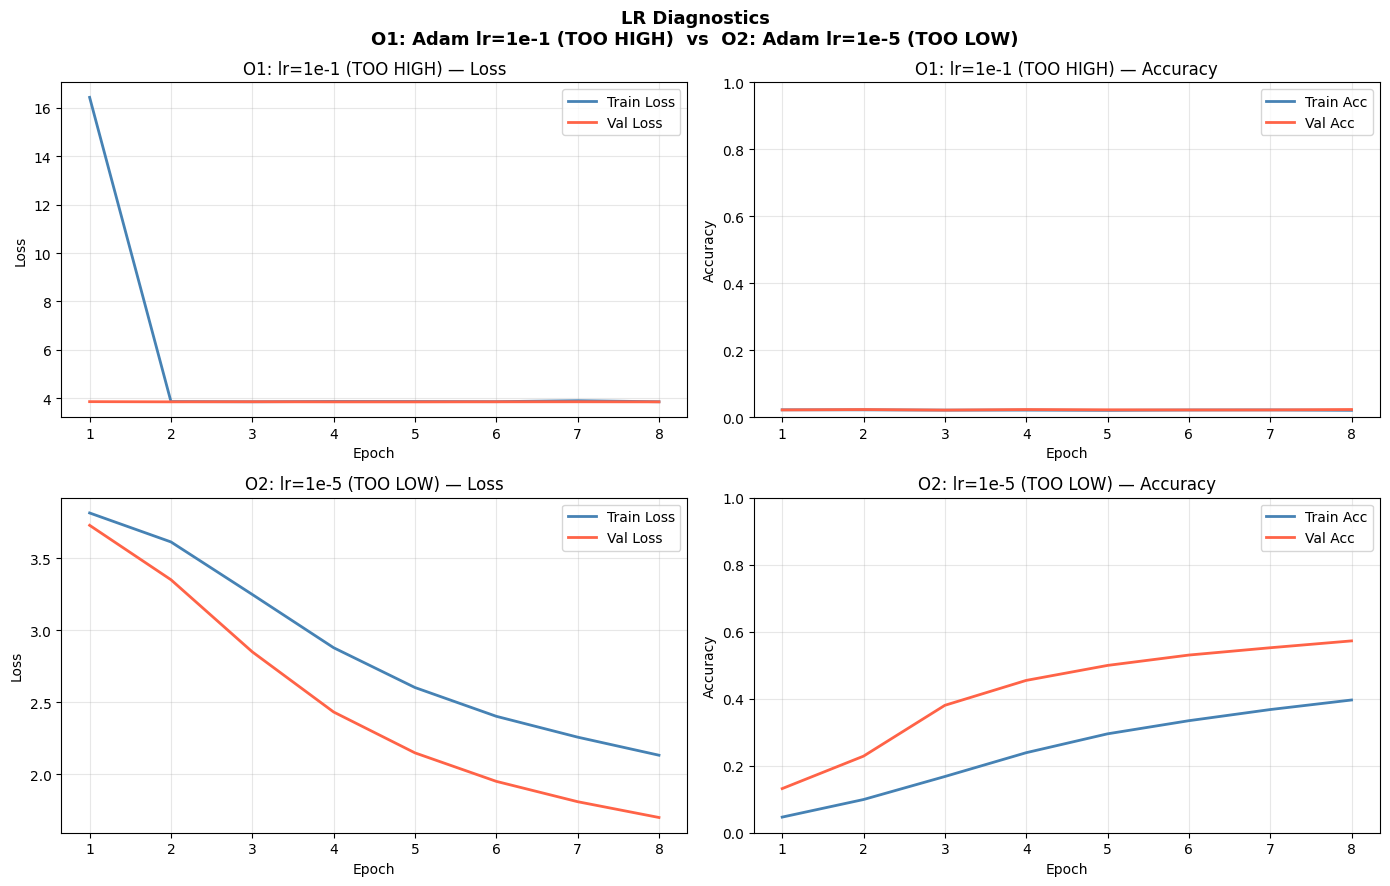

Saved → artifacts\figures\curves_lr_extremes.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'LR Diagnostics\nO1: Adam lr=1e-1 (TOO HIGH)  vs  O2: Adam lr=1e-5 (TOO LOW)',
    fontsize=13, fontweight='bold'
)

ep_o1 = range(1, len(hist_o1['train_loss']) + 1)
ep_o2 = range(1, len(hist_o2['train_loss']) + 1)

# O1 — Loss
axes[0, 0].plot(ep_o1, hist_o1['train_loss'], label='Train Loss', color='steelblue', lw=2)
axes[0, 0].plot(ep_o1, hist_o1['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
axes[0, 0].set_title('O1: lr=1e-1 (TOO HIGH) — Loss')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# O1 — Accuracy
axes[0, 1].plot(ep_o1, hist_o1['train_acc'], label='Train Acc', color='steelblue', lw=2)
axes[0, 1].plot(ep_o1, hist_o1['val_acc'],   label='Val Acc',   color='tomato',    lw=2)
axes[0, 1].set_title('O1: lr=1e-1 (TOO HIGH) — Accuracy')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim([0, 1]); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# O2 — Loss
axes[1, 0].plot(ep_o2, hist_o2['train_loss'], label='Train Loss', color='steelblue', lw=2)
axes[1, 0].plot(ep_o2, hist_o2['val_loss'],   label='Val Loss',   color='tomato',    lw=2)
axes[1, 0].set_title('O2: lr=1e-5 (TOO LOW) — Loss')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# O2 — Accuracy
axes[1, 1].plot(ep_o2, hist_o2['train_acc'], label='Train Acc', color='steelblue', lw=2)
axes[1, 1].plot(ep_o2, hist_o2['val_acc'],   label='Val Acc',   color='tomato',    lw=2)
axes[1, 1].set_title('O2: lr=1e-5 (TOO LOW) — Accuracy')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim([0, 1]); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

fig.tight_layout()
_path = os.path.join(FIGURES_DIR, 'curves_lr_extremes.png')
fig.savefig(_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {_path}')

---
## 6. Сохранение артефактов

In [22]:
# ── best_model.pt ─────────────────────────────────────────────────────────────
best_model_path = os.path.join(ARTIFACTS_DIR, 'best_model.pt')
torch.save(model_e4.state_dict(), best_model_path)
print(f'Saved → {best_model_path}')

Saved → artifacts\best_model.pt


In [23]:
# ── best_config.json ──────────────────────────────────────────────────────────
best_config = {
    'experiment_id':     'E4',
    'based_on':          best_from,
    'dataset':           DATASET_NAME,
    'seed':              SEED,
    'input_size':        28 * 28,
    'hidden_sizes':      HIDDEN_SIZES,
    'num_classes':       NUM_CLASSES,
    'activation':        'relu',
    'dropout_p':         best_kwargs['dropout_p'],
    'use_batchnorm':     best_kwargs['use_batchnorm'],
    'optimizer':         'Adam',
    'lr':                LR_DEFAULT,
    'weight_decay':      0,
    'batch_size':        BATCH_SIZE,
    'train_val_split':   '80/20',
    'normalize':         'mean=0.1736 std=0.3317',
    'early_stopping':    True,
    'patience':          5,
    'epochs_trained':    epochs_e4,
    'best_val_accuracy': round(best_val_acc_e4, 6),
    'best_val_loss':     round(best_val_loss_e4, 6),
    'test_accuracy':     round(test_acc,  6),
    'test_loss':         round(test_loss, 6),
}

best_config_path = os.path.join(ARTIFACTS_DIR, 'best_config.json')
with open(best_config_path, 'w', encoding='utf-8') as f:
    json.dump(best_config, f, indent=2, ensure_ascii=False)
print(f'Saved → {best_config_path}')

Saved → artifacts\best_config.json


In [24]:
# ── runs.csv ──────────────────────────────────────────────────────────────────
def _ms(hidden, dp, bn, extra=''):
    s = f'{hidden}/relu/dropout={dp}/batchnorm={bn}'
    return s + (f'/{extra}' if extra else '')


runs_rows = [
    dict(experiment_id='E1', dataset=DATASET_NAME, seed=SEED,
         model_summary=_ms(HIDDEN_SIZES, 0.0, False),
         optimizer='Adam', lr=LR_DEFAULT, momentum='', weight_decay=0,
         epochs_trained=NUM_EPOCHS_REG,
         best_val_accuracy=round(best_val_acc_e1,  5),
         best_val_loss=    round(best_val_loss_e1, 5)),

    dict(experiment_id='E2', dataset=DATASET_NAME, seed=SEED,
         model_summary=_ms(HIDDEN_SIZES, 0.3, False),
         optimizer='Adam', lr=LR_DEFAULT, momentum='', weight_decay=0,
         epochs_trained=NUM_EPOCHS_REG,
         best_val_accuracy=round(best_val_acc_e2,  5),
         best_val_loss=    round(best_val_loss_e2, 5)),

    dict(experiment_id='E3', dataset=DATASET_NAME, seed=SEED,
         model_summary=_ms(HIDDEN_SIZES, 0.0, True),
         optimizer='Adam', lr=LR_DEFAULT, momentum='', weight_decay=0,
         epochs_trained=NUM_EPOCHS_REG,
         best_val_accuracy=round(best_val_acc_e3,  5),
         best_val_loss=    round(best_val_loss_e3, 5)),

    dict(experiment_id='E4', dataset=DATASET_NAME, seed=SEED,
         model_summary=_ms(HIDDEN_SIZES,
                           best_kwargs['dropout_p'],
                           best_kwargs['use_batchnorm'],
                           'EarlyStopping'),
         optimizer='Adam', lr=LR_DEFAULT, momentum='', weight_decay=0,
         epochs_trained=epochs_e4,
         best_val_accuracy=round(best_val_acc_e4,  5),
         best_val_loss=    round(best_val_loss_e4, 5)),

    dict(experiment_id='O1', dataset=DATASET_NAME, seed=SEED,
         model_summary=_ms(HIDDEN_SIZES,
                           best_kwargs['dropout_p'],
                           best_kwargs['use_batchnorm']),
         optimizer='Adam', lr=1e-1, momentum='', weight_decay=0,
         epochs_trained=NUM_EPOCHS_DIAG,
         best_val_accuracy=round(best_val_acc_o1,  5),
         best_val_loss=    round(best_val_loss_o1, 5)),

    dict(experiment_id='O2', dataset=DATASET_NAME, seed=SEED,
         model_summary=_ms(HIDDEN_SIZES,
                           best_kwargs['dropout_p'],
                           best_kwargs['use_batchnorm']),
         optimizer='Adam', lr=1e-5, momentum='', weight_decay=0,
         epochs_trained=NUM_EPOCHS_DIAG,
         best_val_accuracy=round(best_val_acc_o2,  5),
         best_val_loss=    round(best_val_loss_o2, 5)),

    dict(experiment_id='O3', dataset=DATASET_NAME, seed=SEED,
         model_summary=_ms(HIDDEN_SIZES,
                           best_kwargs['dropout_p'],
                           best_kwargs['use_batchnorm']),
         optimizer='SGD', lr=LR_SGD, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY,
         epochs_trained=NUM_EPOCHS_SGD,
         best_val_accuracy=round(best_val_acc_o3,  5),
         best_val_loss=    round(best_val_loss_o3, 5)),
]

FIELDNAMES = ['experiment_id', 'dataset', 'seed', 'model_summary',
              'optimizer', 'lr', 'momentum', 'weight_decay',
              'epochs_trained', 'best_val_accuracy', 'best_val_loss']

runs_csv_path = os.path.join(ARTIFACTS_DIR, 'runs.csv')
with open(runs_csv_path, 'w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=FIELDNAMES)
    w.writeheader()
    w.writerows(runs_rows)

print(f'Saved → {runs_csv_path}')

Saved → artifacts\runs.csv


---
## 7. Итоговая сводка

In [25]:
import pandas as pd

df = pd.read_csv(runs_csv_path)
display_cols = ['experiment_id', 'optimizer', 'lr', 'momentum',
                'weight_decay', 'epochs_trained',
                'best_val_accuracy', 'best_val_loss']
print(df[display_cols].to_string(index=False))

experiment_id optimizer      lr  momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1      Adam 0.00100       NaN        0.0000              20            0.84876        0.46316
           E2      Adam 0.00100       NaN        0.0000              20            0.85895        0.42782
           E3      Adam 0.00100       NaN        0.0000              20            0.85470        0.43186
           E4      Adam 0.00100       NaN        0.0000              34            0.86015        0.42370
           O1      Adam 0.10000       NaN        0.0000               8            0.02274        3.85551
           O2      Adam 0.00001       NaN        0.0000               8            0.57265        1.70132
           O3       SGD 0.01000       0.9        0.0001              15            0.84437        0.45995


In [26]:
print('\n' + '═' * 52)
print('ФИНАЛЬНЫЙ ИТОГ')
print('═' * 52)
print(f'  Датасет        : EMNIST balanced  (47 классов)')
print(f'  Лучшая модель  : E4  (основана на {best_from} + EarlyStopping)')
print(f'  Обучено эпох   : {epochs_e4}')
print(f'  Val  accuracy  : {best_val_acc_e4:.4f}  ({best_val_acc_e4 * 100:.2f}%)')
print(f'  TEST accuracy  : {test_acc:.4f}  ({test_acc * 100:.2f}%)')

print('\nАртефакты:')
artifact_files = [
    os.path.join(ARTIFACTS_DIR, 'runs.csv'),
    os.path.join(ARTIFACTS_DIR, 'best_model.pt'),
    os.path.join(ARTIFACTS_DIR, 'best_config.json'),
    os.path.join(FIGURES_DIR,   'curves_best.png'),
    os.path.join(FIGURES_DIR,   'curves_lr_extremes.png'),
    os.path.join(FIGURES_DIR,   'curves_regularization_summary.png'),
]
for fpath in artifact_files:
    status = '✓' if os.path.exists(fpath) else '✗  ОТСУТСТВУЕТ'
    print(f'  [{status}]  {fpath}')


════════════════════════════════════════════════════
ФИНАЛЬНЫЙ ИТОГ
════════════════════════════════════════════════════
  Датасет        : EMNIST balanced  (47 классов)
  Лучшая модель  : E4  (основана на E2 + EarlyStopping)
  Обучено эпох   : 34
  Val  accuracy  : 0.8602  (86.02%)
  TEST accuracy  : 0.8545  (85.45%)

Артефакты:
  [✓]  artifacts\runs.csv
  [✓]  artifacts\best_model.pt
  [✓]  artifacts\best_config.json
  [✓]  artifacts\figures\curves_best.png
  [✓]  artifacts\figures\curves_lr_extremes.png
  [✓]  artifacts\figures\curves_regularization_summary.png
